# Week 13: Domain Adaptation - Few-Shots method 
Task 5 — Yerlan Berikov

1. Evaluates the zero-shot baseline (no tweet labels at all)
2. Runs few-shot training for K = 10, 30, 50, 100, 200 samples per class
3. Plots a K-shot learning curve — Macro-F1 vs number of labelled examples

In [8]:
import json, time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import Dataset as TorchDataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments,
)
from sklearn.metrics import accuracy_score, f1_score, classification_report

SEED          = 42
ID2LABEL      = {0: 'negative', 1: 'neutral', 2: 'positive'}
FINETUNED_DIR = '../models/roberta_finetuned'
MAX_LEN       = 128
BATCH_SIZE    = 16
EPOCHS        = 20
LR            = 5e-6
K_SHOTS       = [10, 30, 50, 100, 200]

device = 'cuda' if torch.cuda.is_available() else 'cpu'

## 1. Load Data

In [9]:
tweet_df = pd.read_csv('../data/processed/tweet_final_test.csv')
print(f'Tweet test set: {len(tweet_df):,} rows')
tweet_df['label'].map(ID2LABEL).value_counts()

Tweet test set: 1,740 rows


label
negative    580
positive    580
neutral     580
Name: count, dtype: int64

## 2. Helper Functions

In [ ]:
class SentimentDataset(TorchDataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(texts, truncation=True, padding='max_length', max_length=MAX_LEN)
        self.labels = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': round(accuracy_score(labels, preds), 4),
        'macro_f1': round(f1_score(labels, preds, average='macro', zero_division=0), 4),
    }

def get_logits(model, dataset, device, batch_size=64):
    model.eval()
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size)
    all_logits = []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
            all_logits.append(model(**batch).logits.cpu().numpy())
    return np.concatenate(all_logits)

def sample_k_per_class(df, k, rng):
    few_shot_idx = []
    for label in df['label'].unique():
        idx = df[df['label'] == label].index.tolist()
        few_shot_idx.extend(rng.choice(idx, size=min(k, len(idx)), replace=False).tolist())
    return df.loc[few_shot_idx].reset_index(drop=True), df.drop(index=few_shot_idx).reset_index(drop=True)

tokenizer = AutoTokenizer.from_pretrained(FINETUNED_DIR)

## 3. Zero-Shot Baseline (K = 0)
No tweet labels at all — straight evaluation of the IMDb-trained model on tweets.

In [ ]:
X_all = tweet_df['text_clean'].fillna('').tolist()
y_all = tweet_df['label'].astype(int).tolist()
all_ds = SentimentDataset(X_all, y_all, tokenizer)

model_zs = AutoModelForSequenceClassification.from_pretrained(FINETUNED_DIR).to(device)
logits_zs = get_logits(model_zs, all_ds, device)
preds_zs  = np.argmax(logits_zs, axis=1)

acc_zs = accuracy_score(y_all, preds_zs)
f1_zs  = f1_score(y_all, preds_zs, average='macro', zero_division=0)
print(f'Zero-shot  Accuracy={acc_zs:.4f}  Macro-F1={f1_zs:.4f}')
print(classification_report(y_all, preds_zs, target_names=list(ID2LABEL.values()), zero_division=0))

results = [{'k': 0, 'train_size': 0, 'accuracy': round(acc_zs,4), 'macro_f1': round(f1_zs,4)}]

## 4. K-Shot Training Loop

For each K:
- Sample K examples per class as the training set
- Hold out the rest for testing
- Fine-tune a fresh copy of the IMDb model on the K examples
- Evaluate on the held-out set

In [ ]:
for k in K_SHOTS:
    rng = np.random.default_rng(SEED)
    few_df, held_df = sample_k_per_class(tweet_df, k, rng)

    print(f'\nK={k} | train={len(few_df)} | test={len(held_df)}')

    train_ds = SentimentDataset(few_df['text_clean'].fillna('').tolist(),
                                few_df['label'].astype(int).tolist(), tokenizer)
    test_ds  = SentimentDataset(held_df['text_clean'].fillna('').tolist(),
                                held_df['label'].astype(int).tolist(), tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(FINETUNED_DIR).to(device)

    args = TrainingArguments(
        output_dir=f'../models/roberta_fewshot_k{k}',
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=64,
        learning_rate=LR,
        weight_decay=0.01,
        warmup_ratio=0.1,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='macro_f1',
        greater_is_better=True,
        logging_steps=10,
        seed=SEED,
        fp16=torch.cuda.is_available(),
        report_to='none',
    )

    trainer = Trainer(
        model=model, args=args,
        train_dataset=train_ds, eval_dataset=test_ds,
        compute_metrics=compute_metrics,
    )
    trainer.train()

    model.to(device)
    logits = get_logits(model, test_ds, device)
    preds  = np.argmax(logits, axis=1)
    y_test = held_df['label'].astype(int).tolist()

    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='macro', zero_division=0)
    print(f'K={k}  Accuracy={acc:.4f}  Macro-F1={f1:.4f}')
    print(classification_report(y_test, preds, target_names=list(ID2LABEL.values()), zero_division=0))

    results.append({'k': k, 'train_size': len(few_df), 'accuracy': round(acc,4), 'macro_f1': round(f1,4)})

    # Save after each K
    Path('../logs').mkdir(exist_ok=True)
    with open('../logs/few_shot_metrics.json', 'w') as f:
        json.dump(results, f, indent=2)
    print(f'Saved → ../logs/few_shot_metrics.json')

## 5. Results & Learning Curve

label  train_size  accuracy  macro_f1  F1 gain
  K=0           0    0.5437    0.4350   0.0000
 K=10          30    0.5515    0.4437   0.0087
 K=30          90    0.6921    0.6872   0.2522
 K=50         150    0.6969    0.6966   0.2616
K=100         300    0.7139    0.7115   0.2765
K=200         600    0.7202    0.7175   0.2825


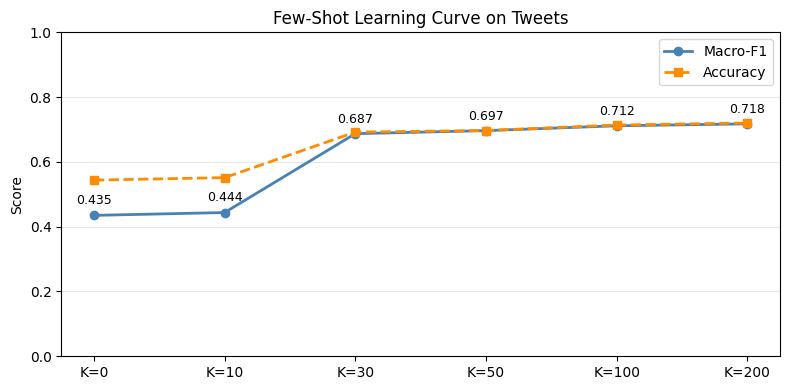

In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt

with open('../logs/few_shot_metrics.json') as f:
    results = json.load(f)

df = pd.DataFrame(results)
df['label']   = df['k'].apply(lambda k: f'K={k}')
df['F1 gain'] = (df['macro_f1'] - df['macro_f1'].iloc[0]).round(4)
print(df[['label', 'train_size', 'accuracy', 'macro_f1', 'F1 gain']].to_string(index=False))

ks   = [r['k'] for r in results]
f1s  = [r['macro_f1'] for r in results]
accs = [r['accuracy'] for r in results]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(len(ks)), f1s,  marker='o', label='Macro-F1',  color='steelblue', linewidth=2)
ax.plot(range(len(ks)), accs, marker='s', label='Accuracy',  color='darkorange', linewidth=2, linestyle='--')

for i, (k, f1) in enumerate(zip(ks, f1s)):
    ax.annotate(f'{f1:.3f}', (i, f1), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

ax.set_xticks(range(len(ks)))
ax.set_xticklabels([f'K={k}' for k in ks])
ax.set_ylabel('Score')
ax.set_title('Few-Shot Learning Curve on Tweets')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()